# Starbucks A/B Testing and Experimentation
## Does a promotion create incremental purchases, and who should receive it?

### Background
The company tested an advertising promotion for a single product priced at `$10`. Sending one promotion costs `$0.15`. A randomized experiment measures whether the promotion increases purchases and whether the added product revenue covers the promotion cost. If the economics vary across customers, customer features can help identify groups for whom the promotion may be worthwhile.

### Questions

1. Does the promotion increase conversion rate?
2. Does broad promotion generate positive net incremental revenue (NIR)?
3. Can logistic regression identify customers whose estimated conversion-rate lift may cover the promotion cost?
4. Does the targeting strategy generate positive NIR when evaluated on separate randomized test data?


### Experiment plan
- **Hypothesis:** Offering the promotion increases the probability that a customer purchases the product.
- **Primary experiment KPI — conversion rate:** the share of customers who purchase during the experiment’s measurement period.
- **Business decision metric - Net incremental revenue (NIR) per promoted customer:** calculated as (conversion rate lift × $10) − $0.15.
- **Randomized groups:** Treatment customers receive the promotion; control customers do not. The planned allocation is 50/50.

  
## Executive summary

The promotion increased conversion rate in the overall experiment, but its average lift was below the 1.5 percentage-point break-even lift under the stated assumptions. Broad promotion therefore did not cover its `$0.15` cost per customer in this simplified NIR analysis.

A logistic-regression-based targeting rule selected 12,744 customers for evaluation in the separate randomized test data. Among selected customers, conversion rate was 2.72% in treatment and 0.70% in control, a lift of 2.01 percentage points (approximate 95% CI: 1.56 to 2.46 percentage points). Estimated NIR was `$0.05` per selected customer (approximate 95% CI: `$0.006` to `$0.096`), meeting the project’s agreed criteria for positive NIR.

The recommendation for the next step is to select and target eligible customers outside the experiment and monitor the conversion rate and NIR during the campaign.  

Profiling the selected customers using business-defined features can help explain who the model selects. This recommendation applies to the promotion tested; a changed promotion would need its own experiment. NIR excludes product and other business costs, so it is not profit.

## 1. Load data and libraries

In [1]:
# Import Path to build file and folder locations.
from pathlib import Path

# Import NumPy for numerical calculations and arrays.
import numpy as np

# Import pandas to load and analyze table-shaped data.
import pandas as pd

# Import Matplotlib to create charts.
import matplotlib.pyplot as plt

# Import the chi-square goodness-of-fit test to check the treatment/control split.
from scipy.stats import chisquare

# Import a test to compare two conversion rates.
from statsmodels.stats.proportion import proportions_ztest

# Import a tool to apply different preparation steps to different columns.
from sklearn.compose import ColumnTransformer

# Import logistic regression to estimate purchase probabilities.
from sklearn.linear_model import LogisticRegression

# Import a tool to connect data preparation steps and a model.
from sklearn.pipeline import make_pipeline

# Import tools to convert categories to numbers and standardize numeric features.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_FOLDER = Path('which customers to target datasets')
TRAIN_PATH = DATA_FOLDER / 'Training.csv'
TEST_PATH = DATA_FOLDER / 'Test.csv'

REVENUE = 10
PROMOTION_COST = 0.15

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

## 2. Data quality checks

This checks the data size, columns, missing values, duplicate customer IDs, outcome values, and whether train and test contain different customers.

In [2]:
train.head()

,ID,Promotion,purchase,V1,V2,V3,V4,V5,V6,V7
0,1,No,0,2,30.443518,-1.165083,1,1,3,2
1,3,No,0,3,32.159350,-0.645617,2,3,2,2
2,4,No,0,2,30.431659,0.133583,1,1,4,2
3,5,No,0,0,26.588914,-0.212728,2,1,4,2
4,8,Yes,0,3,28.044331,-0.385883,1,1,2,2


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84534 entries, 0 to 84533
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         84534 non-null  int64  
 1   Promotion  84534 non-null  object 
 2   purchase   84534 non-null  int64  
 3   V1         84534 non-null  int64  
 4   V2         84534 non-null  float64
 5   V3         84534 non-null  float64
 6   V4         84534 non-null  int64  
 7   V5         84534 non-null  int64  
 8   V6         84534 non-null  int64  
 9   V7         84534 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 6.4+ MB


In [4]:
train['Promotion'].value_counts()

Promotion
Yes    42364
No     42170
Name: count, dtype: int64

In [5]:
train['purchase'].value_counts()

purchase
0    83494
1     1040
Name: count, dtype: int64

In [6]:
#percentage of customers who purchased/did not purchase
train['purchase'].value_counts(normalize=True)

purchase
0    0.987697
1    0.012303
Name: proportion, dtype: float64

In [7]:
print('Training shape:', train.shape)
print('Test shape:', test.shape)
print('Training duplicate IDs:', train['ID'].duplicated().sum())
print('Training missing values:', train.isna().sum().sum())
print('IDs shared across files:', len(set(train['ID']) & set(test['ID'])))

Training shape: (84534, 10)
Test shape: (41650, 10)
Training duplicate IDs: 0
Training missing values: 0
IDs shared across files: 0


**Finding:** The training data contains 84,534 customers, one row per ID, and no duplicate or missing values. Training and test IDs do not overlap. 

Treatment and control are split approximately 50/50. Purchase is highly imbalanced: approximately 99% of customers did not purchase and 1% purchased.

## 3. Check sample ratio mismatch (SRM)

The chi-square goodness-of-fit test checks whether the observed treatment and control counts differ from the planned 50/50 split more than random chance would typically explain.

In [8]:
# Separate the training data by experiment group.
treatment = train[train['Promotion'] == 'Yes']
control = train[train['Promotion'] == 'No']

treatment_count = len(treatment)
control_count = len(control)
expected_count = len(train) / 2

srm_p_value = chisquare(
    [treatment_count, control_count],
    f_exp=[expected_count, expected_count]
).pvalue

print('Treatment count:', treatment_count)
print('Control count:', control_count)
print('Treatment share:', f'{treatment_count / len(train):.2%}')
print('SRM p-value:', round(srm_p_value, 3))

Treatment count: 42364
Control count: 42170
Treatment share: 50.11%
SRM p-value: 0.505


**Finding:** Treatment contains 42,364 customers and control contains 42,170. The treatment share is 50.11%. The SRM test gives p = 0.505, which is greater than 0.05. The observed counts are consistent with the planned 50/50 allocation; the test does not indicate a sample-ratio mismatch.

## 4. Interpret the experiment results and calculate business value

In [9]:
# Calculate the conversion rate in each group.
treatment_conversion_rate = treatment['purchase'].mean()
control_conversion_rate = control['purchase'].mean()

# Calculate the absolute and relative conversion-rate lift.
conversion_rate_lift = treatment_conversion_rate - control_conversion_rate
relative_lift = conversion_rate_lift / control_conversion_rate

# Count purchases in each group for the two-proportion z-test.
treatment_purchases = treatment['purchase'].sum()
control_purchases = control['purchase'].sum()

# Test whether the treatment and control conversion rates differ.
z_stat, p_value = proportions_ztest(
    [treatment_purchases, control_purchases],
    [len(treatment), len(control)]
)

#the standard error estimates the uncertainty in the measured difference between treatment and control.
standard_error = np.sqrt(
    treatment_conversion_rate * (1 - treatment_conversion_rate) / len(treatment)
    + control_conversion_rate * (1 - control_conversion_rate) / len(control)
)

# Calculate the approximate 95% confidence interval for the difference.
ci_low = conversion_rate_lift - 1.96 * standard_error
ci_high = conversion_rate_lift + 1.96 * standard_error

print(f'Treatment conversion rate: {treatment_conversion_rate:.2%}')
print(f'Control conversion rate: {control_conversion_rate:.2%}')
print('')
print(f'Conversion-rate absolute lift: {conversion_rate_lift * 100:.2f} percentage points')
print(f'Relative lift: {relative_lift:.2%}')
print(f'Approximate 95% CI for lift: [{ci_low * 100:.2f}, {ci_high * 100:.2f}] percentage points')
print(f'p-value: {p_value:.3g}')

# Calculate break-even conversion-rate lift from promotion cost and product revenue.
break_even_lift = PROMOTION_COST / REVENUE

# Convert the conversion-rate lift and its confidence interval into NIR.
nir_per_treated_customer = conversion_rate_lift * REVENUE - PROMOTION_COST
nir_ci_low = ci_low * REVENUE - PROMOTION_COST
nir_ci_high = ci_high * REVENUE - PROMOTION_COST

print(' ')
print(f'Break-even conversion-rate lift: {break_even_lift * 100:.2f} percentage points')
print(f'NIR per treated customer: ${nir_per_treated_customer:.2f}')
print(f'Approximate 95% NIR CI per treated customer: [${nir_ci_low:.2f}, ${nir_ci_high:.2f}]')

Treatment conversion rate: 1.70%
Control conversion rate: 0.76%

Conversion-rate absolute lift: 0.95 percentage points
Relative lift: 124.98%
Approximate 95% CI for lift: [0.80, 1.09] percentage points
p-value: 1.11e-35
 
Break-even conversion-rate lift: 1.50 percentage points
NIR per treated customer: $-0.06
Approximate 95% NIR CI per treated customer: [$-0.07, $-0.04]


**Finding:** The experiment provides **strong statistical evidence that offering the promotion increased average conversion rate compared with control** (*p* < 0.001). conversion rate was **1.70% in treatment** and **0.76% in control**, an estimated lift of **0.95 percentage points** (95% CI: **0.80 to 1.09 percentage points**). The confidence interval is entirely above zero, supporting a positive average effect.

However, at `$10` product revenue per purchase, that lift corresponds to about **`$0.08` to `$0.11` in incremental product revenue per treated customer**, below the **`$0.15` promotion cost**. The approximate NIR interval is **`−$0.07` to `−$0.04` per treated customer**. So the promotion significantly increased purchases, but its estimated incremental revenue did not cover the promotion cost. 

**Next step:** Since broad promotion did not cover its cost, use logistic regression to identify customers who may generate positive incremental value from the promotion. 

<details>
<summary>note</summary>

The estimated conversion-rate lift is likely between 0.80 and 1.09 percentage points. Because the entire interval is above zero, the results support a positive average effect of the promotion.

However, the break-even lift is 1.50 percentage points. Since the whole interval is below break-even, the promotion’s estimated added product revenue does not cover its cost under the stated assumptions.

“95% confidence” means that this method would produce intervals containing the true average lift in about 95% of repeated, similar experiments. It doesn’t mean there is a 95% probability that this particular interval contains the true lift.

</details>

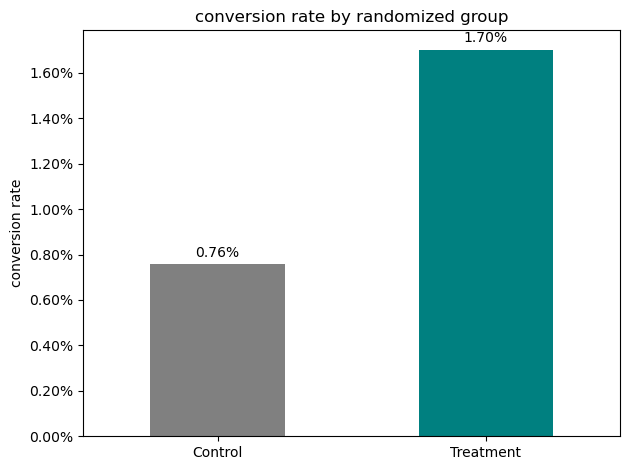

In [10]:
conversion_rates = pd.Series({
    'Control': control_conversion_rate,
    'Treatment': treatment_conversion_rate
})

ax = conversion_rates.plot(
    kind='bar',
    color=['gray', 'teal'],
    rot=0
)

# Add conversion-rate labels above the bars.
ax.bar_label(
    ax.containers[0],
    labels=[f'{rate:.2%}' for rate in conversion_rates],
    padding=3
)

plt.ylabel('conversion rate')
plt.title('conversion rate by randomized group')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
plt.show()

## 5. Build a targeting model with logistic regression

Logistic regression estimates purchase probability from customer features. For each customer, the models estimate purchase probability with and without the promotion. Comparing those estimates helps identify customers who may be more likely to purchase because of the promotion. 

In [11]:
# Choose the customer features the models will use.
features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']

# List the categorical and numeric features.
categorical_features = ['V1', 'V4', 'V5', 'V6', 'V7']
numeric_features = ['V2', 'V3']

# Train two logistic regression models:
# one using treatment customers and one using control customers.

# Prepare categorical and numeric features for the treatment model.
treatment_preprocessing = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('numeric', StandardScaler(), numeric_features)
])

# Connect preprocessing to logistic regression.
treatment_model = make_pipeline(
    treatment_preprocessing,
    LogisticRegression(max_iter=1000)
)

# Fit the treatment model using all treatment customers in Training.csv.
treatment_model.fit(
    treatment[features],
    treatment['purchase']
)

# Prepare categorical and numeric features for the control model.
control_preprocessing = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('numeric', StandardScaler(), numeric_features)
])

# Connect preprocessing to logistic regression.
control_model = make_pipeline(
    control_preprocessing,
    LogisticRegression(max_iter=1000)
)

# Fit the control model using all control customers in Training.csv.
control_model.fit(
    control[features],
    control['purchase']
)

print('Treatment purchases used for training:', treatment['purchase'].sum())
print('Control purchases used for training:', control['purchase'].sum())

Treatment purchases used for training: 721
Control purchases used for training: 319


<details>
<summary>note</summary>

handle_unknown='ignore' tells OneHotEncoder not to fail if it encounters a category during prediction that it didn’t see when fitting the model.

</details>

## 6. Use logistic regression to estimate Test.csv customers’ purchase probabilities with and without the promotion

In [12]:
# Predict purchase probability for each test customer with and without the promotion.
test['conversion_rate_if_treated'] = treatment_model.predict_proba(test[features])[:, 1]
test['conversion_rate_if_control'] = control_model.predict_proba(test[features])[:, 1]

## 7. Select customers whose estimated uplift exceeds the break-even lift

In [13]:
# Estimate the extra purchase probability associated with the promotion.
test['estimated_uplift'] = test['conversion_rate_if_treated'] - test['conversion_rate_if_control']

# Select customers whose estimated incremental revenue exceeds the promotion cost.
test['selected_for_promotion'] = test['estimated_uplift'] > break_even_lift

print('Customers selected:', int(test['selected_for_promotion'].sum()))
print(f'Share selected: {test['selected_for_promotion'].mean():.1%}')

Customers selected: 12744
Share selected: 30.6%


## 8. Evaluate NIR for the selected customers

In [14]:
# Keep only test customers selected by the targeting rule.
selected_test = test[test['selected_for_promotion']]

# Separate selected customers by their randomized experiment assignment.
selected_treatment = selected_test[selected_test['Promotion'] == 'Yes']
selected_control = selected_test[selected_test['Promotion'] == 'No']

print('Selected treatment customers:', len(selected_treatment))
print('Selected control customers:', len(selected_control))

# Calculate conversion rate in each selected randomized group.
selected_treatment_rate = selected_treatment['purchase'].mean()
selected_control_rate = selected_control['purchase'].mean()

# Calculate the conversion-rate lift for selected customers.
selected_purchase_rate_lift = selected_treatment_rate - selected_control_rate

# Calculate estimated NIR per selected customer.
selected_nir_per_customer = (
    selected_purchase_rate_lift * REVENUE - PROMOTION_COST
)

# Calculate the standard error and approximate 95% confidence interval for lift.
selected_standard_error = np.sqrt(
    selected_treatment_rate * (1 - selected_treatment_rate) / len(selected_treatment)
    + selected_control_rate * (1 - selected_control_rate) / len(selected_control)
)
selected_lift_ci_low = selected_purchase_rate_lift - 1.96 * selected_standard_error
selected_lift_ci_high = selected_purchase_rate_lift + 1.96 * selected_standard_error

# Convert the lift confidence interval into an NIR confidence interval.
selected_nir_ci_low = selected_lift_ci_low * REVENUE - PROMOTION_COST
selected_nir_ci_high = selected_lift_ci_high * REVENUE - PROMOTION_COST

print('')
print(f'Selected treatment conversion rate: {selected_treatment_rate:.2%}')
print(f'Selected control conversion rate: {selected_control_rate:.2%}')
print(f'Selected-group conversion-rate lift: {selected_purchase_rate_lift * 100:.2f} percentage points')
print(f'Approximate 95% CI for lift: [{selected_lift_ci_low * 100:.2f}, {selected_lift_ci_high * 100:.2f}] percentage points')
print('')
print(f'NIR per selected customer: ${selected_nir_per_customer:.2f}')
print(f'Approximate 95% NIR CI per customer: [${selected_nir_ci_low:.3f}, ${selected_nir_ci_high:.3f}]')

Selected treatment customers: 6335
Selected control customers: 6409

Selected treatment conversion rate: 2.72%
Selected control conversion rate: 0.70%
Selected-group conversion-rate lift: 2.01 percentage points
Approximate 95% CI for lift: [1.56, 2.46] percentage points

NIR per selected customer: $0.05
Approximate 95% NIR CI per customer: [$0.006, $0.096]


## 9. Conclusion and recommendation

The promotion increased conversion rate in the overall experiment, but its average lift was below the 1.5 percentage-point break-even lift under the stated assumptions. Broad promotion did not cover its promotion cost in this simplified NIR analysis.

The targeting rule selected 12,744 customers for evaluation. Among them, conversion rate was 2.72% in treatment and 0.70% in control, a lift of 2.01 percentage points (approximate 95% CI: 1.56 to 2.46 percentage points). Estimated NIR was `$0.05` per selected customer (approximate 95% CI: `$0.006` to `$0.096`). Because estimated NIR is positive and its confidence interval is entirely above zero, the targeting strategy meets the agreed criteria.

**Recommendation:** Apply the targeting rule to eligible customers outside the experiment and monitor conversion rate and NIR during the campaign. 

## 10. Methods and limitations

**Methods used:** A/B testing and experimentation analysis, two-proportion significance test, chi-square goodness-of-fit test for sample-ratio mismatch (SRM), logistic regression for model-based treatment-effect estimation (uplift modeling), and Python data analysis with pandas, NumPy, and Matplotlib

**Limitations:** The NIR calculation uses product revenue and promotion cost only; it excludes product and other business costs, so it is not profit. Customer features are anonymized, so their business meaning is unknown.